<div class='bar_title'></div>

*Simulation for Decision Making (S4DM)*

# Exercise 7: Output Analysis (Single Model)

Summer Semester 25


Gunther Gust & Ignacio Ubeda <br>
Chair for Enterprise AI <br>
Data Driven Decisions Group <br>
Center for Artificial Intelligence and Data Science (CAIDAS)

<img src="images/d3.png" style="width:20%; float:left;" />

<img src="images/CAIDASlogo.png" style="width:20%; float:left;" />

# Agenda

* Time-based Performance Measure
* Confidence Interval for the $\gamma$-Quantile
* Proportion Performance Measure

## Car wash example

In [1]:
import os
import simpy
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
class EventLogger:
    def __init__(self):
        self.logs = []
        self.replication = None #replication number
        self.seed = None #seed used for the replication
    
    def set_replication_info(self, replication, seed):
        self.replication = replication
        self.seed = seed

    def log_car_arrival(self, entity, time, queue_length):
        self.logs.append({'replication_id': self.replication, 'seed': self.seed, #replication info
                          'event_time': time, 'event_name': 'car_arrival', 'event_key': entity, #simulation info
                          'queue_length': queue_length #queue info
                          })
    
    def log_car_wash_request(self, entity, time, queue_length):
        self.logs.append({'replication_id': self.replication, 'seed': self.seed, #replication info
                          'event_time': time, 'event_name': 'car_wash_request', 'event_key': entity, #simulation info
                          'queue_length': queue_length #queue info
                          })

    def log_car_departure(self, entity, time, queue_length):
        self.logs.append({'replication_id': self.replication, 'seed': self.seed, #replication info
                          'event_time': time, 'event_name': 'car_departure', 'event_key': entity, #simulation info
                          'queue_length': queue_length #queue info
                          })

    def get_logs_df(self):
        return pd.DataFrame(self.logs)
    
    def dump_logs_df(self, filepath=None):
        if filepath is None: 
            filepath = "logs.csv"

        self.get_logs_df().to_csv(filepath, index=False)

In [3]:
class Carwash:
    def __init__(self, env, num_machines, logger):
        self.env = env
        self.machine = simpy.Resource(env, num_machines)
        self.logger = logger

    def wash(self):
        yield self.env.timeout(np.random.exponential(1/0.3))

In [4]:
class Car:
    def __init__(self, env, name, carwash, logger):
        self.env = env
        self.name = name
        self.logger = logger

        self.env.process(self.run(carwash))

    def run(self, carwash):
        
        # Log the arrival
        self.logger.log_car_arrival(self.name, self.env.now, len(carwash.machine.queue))
        with carwash.machine.request() as request:
            yield request

            # Log the request for car wash
            self.logger.log_car_wash_request(self.name, self.env.now, len(carwash.machine.queue))
            yield self.env.process(carwash.wash())

            #Log the departure
            self.logger.log_car_departure(self.name, self.env.now, len(carwash.machine.queue))

In [5]:
def car_generator(env, carwash, logger):
    car_count = 0

    # Create cars while the simulation is running
    while True:
        yield env.timeout(np.random.exponential(1/0.5))
        Car(env, f'Car {car_count}', carwash, logger)
        car_count += 1

## Run Simulation (now, for multiple replications)

In [6]:
# parameters
NUM_MACHINES = 2    # Number of machines in the carwash
SIM_TIME = 8*60       # Simulation time in minutes
N_REPLICATIONS = 20 # Number of Replications

# Setup and start the simulation
print('Running Simulation...')

#define logger (same for all replications)
logger = EventLogger()

#Compute a pool of seeds that is larger than the number of replications
safe_factor = 10
pool_of_seeds = range(1, N_REPLICATIONS * safe_factor)

#get a list of seeds of length: N_REPLICATIONS from a pool of seeds. 
#We set replace=False to ensure that we don't reuse the same seed twice.
list_of_seeds = np.random.choice(pool_of_seeds, size=N_REPLICATIONS, replace=False)

for i, seed in enumerate(list_of_seeds):
    print(f'Running Replication {i} with seed: {seed} ...')

    #set random seed
    np.random.seed(seed)

    #set replication id and random seed
    logger.set_replication_info(i, seed)

    # Create an environment and start the setup process
    env = simpy.Environment()

    #define resources
    carwash = Carwash(env, NUM_MACHINES, logger)

    #define processes
    env.process(car_generator(env, carwash, logger))

    # Execute
    env.run(until=SIM_TIME)

print('... Done')

Running Simulation...
Running Replication 0 with seed: 140 ...
Running Replication 1 with seed: 176 ...
Running Replication 2 with seed: 192 ...
Running Replication 3 with seed: 129 ...
Running Replication 4 with seed: 11 ...
Running Replication 5 with seed: 130 ...
Running Replication 6 with seed: 148 ...
Running Replication 7 with seed: 50 ...
Running Replication 8 with seed: 96 ...
Running Replication 9 with seed: 84 ...
Running Replication 10 with seed: 46 ...
Running Replication 11 with seed: 9 ...
Running Replication 12 with seed: 169 ...
Running Replication 13 with seed: 5 ...
Running Replication 14 with seed: 163 ...
Running Replication 15 with seed: 2 ...
Running Replication 16 with seed: 104 ...
Running Replication 17 with seed: 146 ...
Running Replication 18 with seed: 194 ...
Running Replication 19 with seed: 51 ...
... Done


In [7]:
events_df = logger.get_logs_df()

events_df

,replication_id,seed,event_time,event_name,event_key,queue_length
0,0,140,2.755903,car_arrival,Car 0,0
1,0,140,2.755903,car_wash_request,Car 0,0
2,0,140,2.759187,car_departure,Car 0,0
3,0,140,2.986124,car_arrival,Car 1,0
4,0,140,2.986124,car_wash_request,Car 1,0
...,...,...,...,...,...,...
14487,19,51,472.871888,car_departure,Car 247,0
14488,19,51,475.026234,car_departure,Car 250,0
14489,19,51,476.576170,car_arrival,Car 251,0
14490,19,51,476.576170,car_wash_request,Car 251,0


# Exercise / Tasks

## Task 1: Estimate Confidence Interval for Queue Length

We want to compute a confidence interval for the time-weighted average queue length.

-----

**Task 1.1: Plot the queue length over time for the first 3 replications. Understand the range of your output measurement in each replication. Is this stable ?**

<Axes: xlabel='event_time', ylabel='queue_length'>

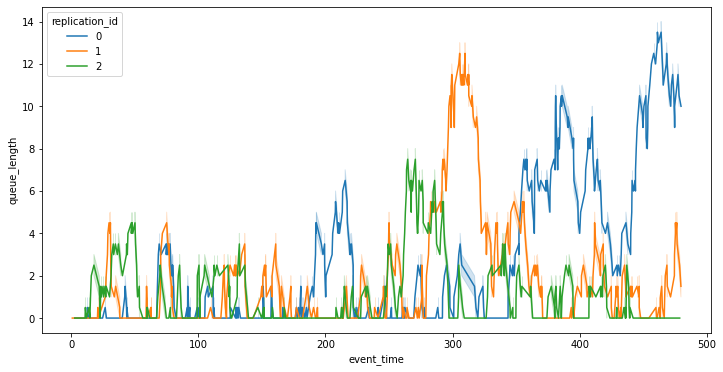

In [8]:
replication_id = [0, 1, 2]
queue_length_df = events_df.query('replication_id in @replication_id')[['replication_id', 'event_time', 'queue_length']].drop_duplicates()

#show queue length over time for the first replication
plt.figure(figsize=(12, 6))
sns.lineplot(data=queue_length_df, 
             x='event_time', y='queue_length', 
             hue='replication_id', palette='tab10')

**Task 1.2: Compute the time-weighted average of the queue length for each replication**, i.e. :

$$
\hat{L}^{(r)} = \frac{1}{T^{(r)}} \sum_{i=1}^{n} q^{(r)}_i \cdot (t^{(r)}_{i+1} - t^{(r)}_i)
$$

Where:
- $q^{(r)}_i$ is the queue length during interval $[t^{(r)}_i, t^{(r)}_{i+1})$ for replication $r$,
- $T^{(r)} = t^{(r)}_n - t^{(r)}_0$ is the total simulation time of replication $r$.

In [9]:
# Get the queue length over time for each replication
queue_length_df = events_df[['replication_id', 'event_time', 'queue_length']].drop_duplicates()

#compute diff of event time and its lag for each replication: (t_i+1 - t_i)
queue_length_df['event_time_diff'] = queue_length_df.groupby('replication_id')['event_time'].diff()

#remove nan (first row of each replication)
queue_length_df = queue_length_df.dropna(subset=['event_time_diff'])

#compute: q * diff
queue_length_df['q_times_diff'] = queue_length_df['queue_length'] * queue_length_df['event_time_diff']
display(queue_length_df.head())

#compute the time-weighted average of the queue length for each replication
avg_queue_length_df = queue_length_df\
                        .groupby('replication_id')\
                        .agg(
                            Q_sum=('q_times_diff', 'sum'),
                            T=('event_time_diff', 'sum') #note that this is the total simulation time for each replication
                        )\
                        .assign(
                            L_hat=lambda x: x['Q_sum'] / x['T']  # compute the time-weighted average of the queue length
                        )\
                        .reset_index()
    
avg_queue_length_df.head()

,replication_id,event_time,queue_length,event_time_diff,q_times_diff
2,0,2.759187,0,0.003284,0.0
3,0,2.986124,0,0.226937,0.0
5,0,2.992692,0,0.006568,0.0
6,0,3.689678,0,0.696987,0.0
8,0,4.013136,0,0.323458,0.0


,replication_id,Q_sum,T,L_hat
0,0,1306.812304,476.933075,2.740033
1,1,917.086205,478.736404,1.915639
2,2,583.349569,475.824042,1.225977
3,3,969.169831,477.944286,2.027788
4,4,841.073604,478.207596,1.758804


**Task 1.3: Compute a confidence interval for the time-weighted average of the queue length (accross replications). Use the following formula:**

<img src="images/ex6_ciformula_lecture.png" style="width:20%" />

**For gettint the t value, you may want to use `stats.t.ppf` from `scipy`. Check the [reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html) for more details.**



In [10]:
#significance level
alpha = 0.05

#compute mean, std and sample size
sample_size = avg_queue_length_df['replication_id'].nunique()
sample_mean = avg_queue_length_df['L_hat'].mean()
sample_std = avg_queue_length_df['L_hat'].std()

print(f"sample mean: {sample_mean}")
print(f"sample std: {sample_std}")

#Calculate t confidence interval

# Calculate the t-value for a 95% confidence interval (two-sided)
t_value = stats.t.ppf(1-alpha/2, sample_size - 1) 

# Calculate the half-width of the confidence interval
ci_halfwidth = t_value * sample_std / np.sqrt(sample_size)

#calculate the lower and upper bounds of the confidence interval
ci_lb = sample_mean - ci_halfwidth
ci_ub = sample_mean + ci_halfwidth

print(f"t confidence int: [{ci_lb}, {ci_ub}]") 

sample mean: 3.090752999187848
sample std: 1.6449234176442082
t confidence int: [2.3209051422728852, 3.860600856102811]


## Task 2: Confidence Interval for the $\gamma$-Quantile

We'd like to compute a confidence interval for the $\gamma$-quantile of the time-weighted average queue length.

-----

**Task 2.1: Sort `avg_queue_length_df` by `L_hat` ($\hat{L}^{(r)}$) ascending. Create a `rank` column to get the position of the rows of the sorted DataFrame.**

In [11]:
#read the average queue length DataFrame
avg_queue_length_df = pd.read_csv(os.path.join('data', 'avg_queue_length.csv'))
display(avg_queue_length_df.head())

#sort by L_hat (ascending)
avg_queue_length_df = avg_queue_length_df.sort_values(by='L_hat', ascending=True)

#create rank column
avg_queue_length_df['rank'] = np.arange(1, avg_queue_length_df.shape[0]+1)

display(avg_queue_length_df.head())

,replication_id,L_hat
0,0,2.010731
1,1,3.094533
2,2,2.660925
3,3,2.363855
4,4,1.610803


,replication_id,L_hat,rank
5,5,0.610997,1
18,18,1.031871,2
12,12,1.225977,3
9,9,1.427762,4
10,10,1.592489,5


**Task 2.2: Compute the rank bounds**, i.e. :

$$
j = \left\lfloor n\gamma - z_{\alpha/2} \cdot \sqrt{n\gamma(1 - \gamma)} \right\rfloor
$$

$$
k = \left\lceil n\gamma + z_{\alpha/2} \cdot \sqrt{n\gamma(1 - \gamma)} \right\rceil
$$

Where:
- $n$ is the sample size
- $\gamma$ is the quantile. Assume $\gamma=0.8$
- $z_{\alpha/2}$ is the critical value from the standard normal distribution corresponding to the confidence level $1 - \alpha$. Assume $\alpha = 0.05$
- $\lfloor \cdot \rfloor$ and $\lceil \cdot \rceil$ are floor and ceiling functions to ensure integer ranks.


**Hint:** For gettint the z value, you may want to use `stats.norm.ppf` from `scipy`. Check the [reference](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html) for more details.

In [12]:
alpha = 0.05
quantile = 0.8
sample_size = avg_queue_length_df.shape[0]

#compute z-value
z_value = stats.norm.ppf(1-alpha/2)

#compute quantile lower and upper bounds
j = np.floor(sample_size * quantile - z_value * np.sqrt(sample_size * quantile * (1-quantile)))
k = np.ceil(sample_size * quantile + z_value * np.sqrt(sample_size * quantile * (1-quantile)))

print(f"j (lower bound): {j} | k (upper bound): {k}")

j (lower bound): 12.0 | k (upper bound): 20.0


**Task 2.3: Compute the bounds of the confidence interval with the indexes of the sorted DataFrame (i.e. the `rank` column, $j$ and $k$).**

In [13]:
#compute the confidence interval
ci_lb = avg_queue_length_df.loc[avg_queue_length_df['rank'] == j]['L_hat'].values[0]
ci_ub = avg_queue_length_df.loc[avg_queue_length_df['rank'] == k]['L_hat'].values[0]

print(f"The {100*(1-alpha)}% CI {quantile}-quantile is [{ci_lb:.4f}, {ci_ub:.4f}]")

The 95.0% CI 0.8-quantile is [2.3639, 9.4537]


## Task 3: Composed Performance Statistics

We want to compute the proportion of time where the queue length is above $k_0$

-----

**Task 3.1: Compute, for each replication, the proportion of time the queue length is above $k_0 = 2.0$. Then compute the average of this metric accross replications.**

Recall that:

$$
\text{Performance} = \frac{1}{T} \int_0^T \mathbb{1}\{Q(t) > k_0\} \, dt
$$

Where:

- $Q(t)$ is the queue length at time $t$,
- $k_0$ is the threshold value,
- The indicator function counts only those time intervals where $Q(t) > k_0$



In [14]:
k0 = 2.0 #threshold for the queue length

# Get the queue length over time for each replication
queue_length_df = events_df[['replication_id', 'event_time', 'queue_length']].drop_duplicates()

#compute diff of event time and its lag for each replication: (t_i+1 - t_i)
queue_length_df['event_time_diff'] = queue_length_df.groupby('replication_id')['event_time'].diff()

#remove nan (first row of each replication)
queue_length_df = queue_length_df.dropna(subset=['event_time_diff'])

#compute: 1 if q >= k0, 0 otherwise
queue_length_df['q_greater_k0'] = (queue_length_df['queue_length'] > k0).astype(int)

#compute: 1(if q > k0) * diff
queue_length_df['q_times_diff'] = queue_length_df['q_greater_k0'] * queue_length_df['event_time_diff']

display(queue_length_df.head())

#compute the proportion of time where the queue length is above k0
prop_time_above_k0_df = queue_length_df\
                        .groupby('replication_id')\
                        .agg(
                            Q_sum=('q_times_diff', 'sum'),
                            T=('event_time_diff', 'sum') #note that this is the total simulation time for each replication
                        )\
                        .assign(
                            performance=lambda x: x['Q_sum'] / x['T']  # compute the time-weighted average of the queue length
                        )\
                        .reset_index()
    
display(prop_time_above_k0_df.head())

#compute mean
print(f"mean proportion of time above k0: {prop_time_above_k0_df['performance'].mean():.4f}")

,replication_id,event_time,queue_length,event_time_diff,q_greater_k0,q_times_diff
2,0,2.759187,0,0.003284,0,0.0
3,0,2.986124,0,0.226937,0,0.0
5,0,2.992692,0,0.006568,0,0.0
6,0,3.689678,0,0.696987,0,0.0
8,0,4.013136,0,0.323458,0,0.0


,replication_id,Q_sum,T,performance
0,0,176.522512,476.933075,0.370120
1,1,128.551497,478.736404,0.268523
2,2,93.631069,475.824042,0.196777
3,3,164.018576,477.944286,0.343175
4,4,138.421951,478.207596,0.289460


mean proportion of time above k0: 0.4126


**Task 3.2: Pack the code into a function `compute_proportion_time_above_k0(events_df, k0)` that takes the `events_df` DataFrame and the threshold `k0` as input and returns the average proportion of time the queue length is above $k_0$ across all replications.**

In [15]:
def compute_proportion_time_above_k0(events_df, k0):
    """
    Compute the average proportion of time the queue length is above k0 across all replications.
    
    Parameters:
    - events_df: DataFrame containing the event logs
    - k0: threshold for the queue length
    
    Returns:
    - Average proportion of time the queue length is above k0 across all replications
    """
    
    # Get the queue length over time for each replication
    queue_length_df = events_df[['replication_id', 'event_time', 'queue_length']].drop_duplicates()

    #compute diff of event time and its lag for each replication: (t_i+1 - t_i)
    queue_length_df['event_time_diff'] = queue_length_df.groupby('replication_id')['event_time'].diff()

    #remove nan (first row of each replication)
    queue_length_df = queue_length_df.dropna(subset=['event_time_diff'])

    #compute: 1 if q >= k0, 0 otherwise
    queue_length_df['q_greater_k0'] = (queue_length_df['queue_length'] > k0).astype(int)

    #compute: 1(if q > k0) * diff
    queue_length_df['q_times_diff'] = queue_length_df['q_greater_k0'] * queue_length_df['event_time_diff']

    #compute the proportion of time where the queue length is above k0
    prop_time_above_k0_df = queue_length_df\
                            .groupby('replication_id')\
                            .agg(
                                Q_sum=('q_times_diff', 'sum'),
                                T=('event_time_diff', 'sum') #note that this is the total simulation time for each replication
                            )\
                            .assign(
                                performance=lambda x: x['Q_sum'] / x['T']  # compute the time-weighted average of the queue length
                            )\
                            .reset_index()
    
    return prop_time_above_k0_df['performance'].mean()


print(f"mean proportion of time above k0: {compute_proportion_time_above_k0(events_df, k0=2.0):.4f}")

mean proportion of time above k0: 0.4126


**Task 3.3: Compute the average proportion of time above $k_0$ for a range of $k_0$ values between 0 and 20 at intervals of 0.1. Then plot the average proportion over $k_0$. How can you interpret the plot?.**

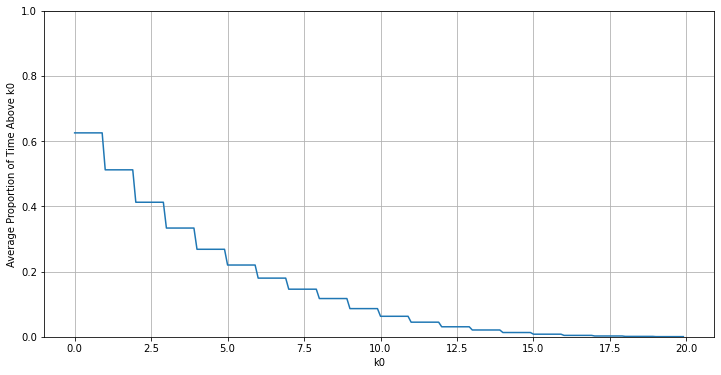

In [16]:
k0_values = np.arange(0.0, 20.0, 0.1)
proportions = [compute_proportion_time_above_k0(events_df, k0) for k0 in k0_values]

#plot average proportion over k0
plt.figure(figsize=(12, 6))
sns.lineplot(x=k0_values, y=proportions)
plt.xlabel('k0')
plt.ylabel('Average Proportion of Time Above k0')
plt.ylim(0, 1)
plt.grid()
plt.show()


## Task 4: Welch’s Method

We'd like to implement the Welch's Method to detect and remove the initial transient phase of 24/7 simulation run.

-----

In [54]:
df = pd.read_csv(os.path.join('data', 'initial_transient_data.csv'))

df.head()

,replication_id,event_time,queue_length
0,0,0,0.000000
1,0,1,0.000000
2,0,2,0.000000
3,0,3,0.000000
4,0,4,0.497787


**Task 4.1: Visualize the queue-length over time for a couple of replications. Make sure that each series corresponds to a different replication**

replication_id,0,1,2,3,4,5,6,7,8,9
event_time,,,,,,,,,,
0,0.000000,1.523980,0.131765,1.302227,0.648583,0.293508,0.000000,0.222077,0.000000,0.332466
1,0.000000,0.922895,0.000000,0.000000,1.319221,1.325333,0.000000,1.077502,0.139744,0.000000
2,0.000000,0.000000,0.000000,0.814045,0.000000,0.842375,2.083544,1.111796,0.055102,0.000000
3,0.000000,0.000000,1.588848,1.458443,0.814611,1.128543,0.000000,1.555705,1.596394,0.079317
4,0.497787,1.082235,3.852260,0.668528,0.559626,0.451284,0.000000,1.139187,1.374073,0.876589
5,0.000000,0.944859,1.453950,0.000000,2.421902,0.034042,0.390052,1.114213,0.000000,0.413970
6,1.329914,1.255930,0.555334,1.508816,0.597107,2.192676,0.120679,0.657521,0.000000,0.476319
7,0.000000,0.599584,2.027556,0.687183,0.636727,0.853789,1.672483,0.000000,2.119339,0.000000
8,0.000000,1.213677,0.390333,1.656335,1.496729,1.022057,0.000000,0.689229,1.710426,0.849630


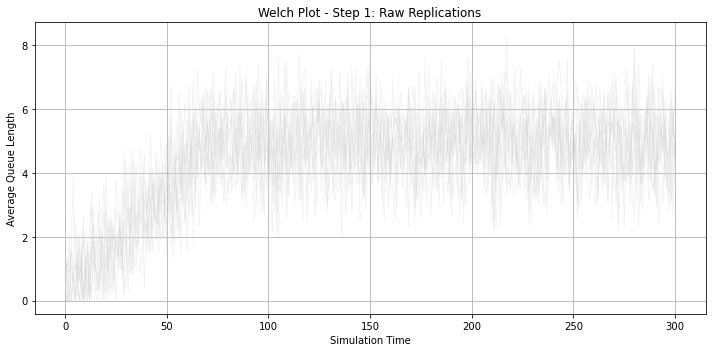

In [55]:
df_pivot = df.pivot(index='event_time', columns='replication_id', values='queue_length')
display(df_pivot.head(10))

plt.figure(figsize=(10, 5))

for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], color='lightgray', alpha=0.3, linewidth=0.8)

plt.xlabel('Simulation Time')
plt.ylabel('Average Queue Length')
plt.title('Welch Plot - Step 1: Raw Replications')
plt.grid(True)
plt.tight_layout()
plt.show()

**Task 4.2: Smooth (using a moving average) the series within each replication. Plot the smoothed and raw series in the same plot**

In [57]:
smoothed_df = df_pivot.rolling(window=10, center=True).mean()
smoothed_df.head(10) 

replication_id,0,1,2,3,4,5,6,7,8,9
event_time,,,,,,,,,,
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.204273,0.754316,1.000004,0.809558,0.854714,0.814361,0.622274,0.986111,0.727835,0.569442
6,0.288170,0.744762,1.098595,0.792203,0.905700,0.854777,0.733020,1.058152,0.727835,0.536195
7,0.288170,0.760337,1.235003,0.809521,0.773778,0.884997,0.910356,1.006939,0.904797,0.663900
8,0.343723,0.764188,1.383734,0.815511,1.002572,0.805375,0.702001,0.965488,0.899286,0.753644


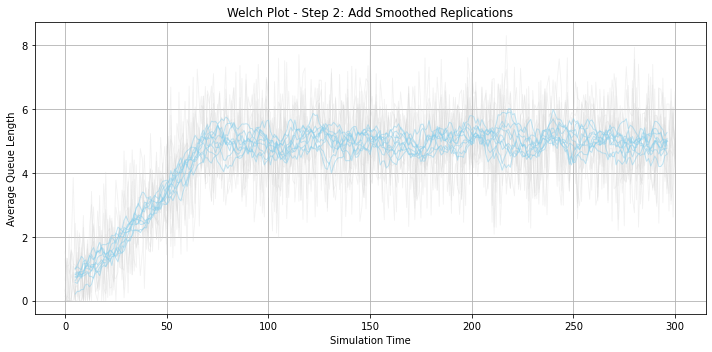

In [58]:
plt.figure(figsize=(10, 5))

# Raw
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], color='lightgray', alpha=0.3, linewidth=0.8)

# Smoothed
for col in smoothed_df.columns:
    plt.plot(smoothed_df.index, smoothed_df[col], color='skyblue', alpha=0.5, linewidth=1)

plt.xlabel('Simulation Time')
plt.ylabel('Average Queue Length')
plt.title('Welch Plot - Step 2: Add Smoothed Replications')
plt.grid(True)
plt.tight_layout()
plt.show()

**Task 4.3: Aggregate the curve across replications. Plot the smoothed (across replications) and raw series in the same plot**

In [60]:
mean_over_time = smoothed_df.mean(axis=1)
mean_over_time_df = mean_over_time.to_frame(name='smoothed_mean')

mean_over_time_df.head(10)

,smoothed_mean
event_time,
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,0.734289
6,0.773941
7,0.823780
8,0.843552


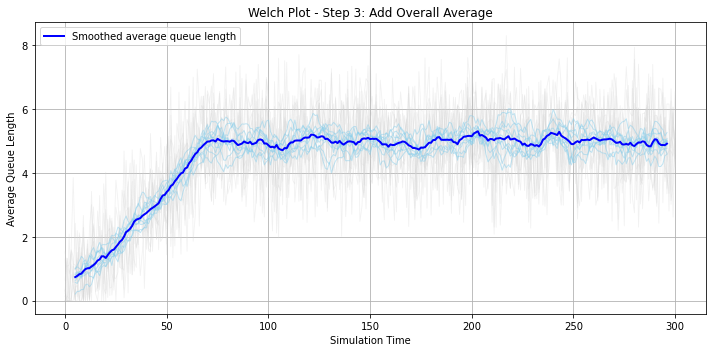

In [61]:
plt.figure(figsize=(10, 5))

# Raw
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], color='lightgray', alpha=0.3, linewidth=0.8)

# Smoothed
for col in smoothed_df.columns:
    plt.plot(smoothed_df.index, smoothed_df[col], color='skyblue', alpha=0.5, linewidth=1)

# Overall mean
plt.plot(mean_over_time.index, mean_over_time, color='blue', linewidth=2, label='Smoothed average queue length')

plt.xlabel('Simulation Time')
plt.ylabel('Average Queue Length')
plt.title('Welch Plot - Step 3: Add Overall Average')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Task 4.4: Choose $t_{\text{warm-up}}$ where the average curve flattens.**




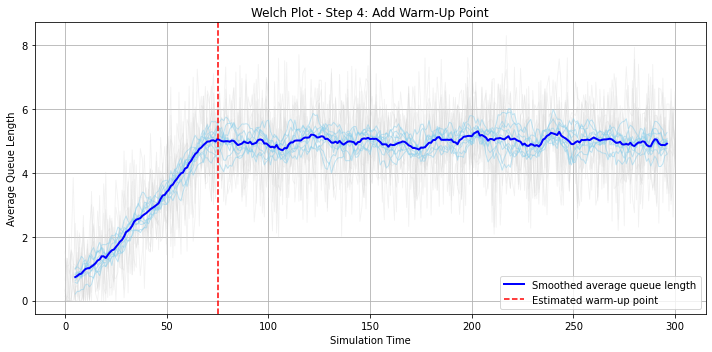

Estimated warm-up point: 75


In [63]:
plt.figure(figsize=(10, 5))

# Raw
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], color='lightgray', alpha=0.3, linewidth=0.8)

# Smoothed
for col in smoothed_df.columns:
    plt.plot(smoothed_df.index, smoothed_df[col], color='skyblue', alpha=0.5, linewidth=1)

# Overall mean
plt.plot(mean_over_time.index, mean_over_time, color='blue', linewidth=2, label='Smoothed average queue length')

# Warm-up line
t_warm_up = 75  # Estimated warm-up point
plt.axvline(x=t_warm_up, color='red', linestyle='--', label='Estimated warm-up point')

plt.xlabel('Simulation Time')
plt.ylabel('Average Queue Length')
plt.title("Welch Plot - Step 4: Add Warm-Up Point")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Estimated warm-up point:", t_warm_up)